**<h2>Olist Ecommerce Data Set</h2>**

**Question:**

"What drives late deliveries and low review scores, which product categories/sellers/regions generate the highest and lowest revenue, and how much revenue is at risk from poor delivery performance and dissatisfied customers?"

**Importing Libraries**

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sea 

**Loading CSV Files of Olist data Set**


In [2]:
orders = pd.read_csv('Olist/olist_orders_dataset.csv')
order_items = pd.read_csv('Olist/olist_order_items_dataset.csv')
order_payments = pd.read_csv('Olist/olist_order_payments_dataset.csv')
order_reviews = pd.read_csv('Olist/olist_order_reviews_dataset.csv')
customers = pd.read_csv('Olist/olist_customers_dataset.csv')
products = pd.read_csv('Olist/olist_products_dataset.csv')
sellers = pd.read_csv('Olist/olist_sellers_dataset.csv')
geolocation = pd.read_csv('Olist/olist_geolocation_dataset.csv')
category_translation = pd.read_csv('Olist/product_category_name_translation.csv')

**Removed Duplicates From Order Reviews Table**


In [3]:
order_reviews['order_id'].duplicated().sum()

order_reviews_dedup = order_reviews.sort_values('review_creation_date').drop_duplicates(subset='order_id', keep='last')
print(len(order_reviews), '->', len(order_reviews_dedup))

99224 -> 98673


**Payment Aggregation**

In [4]:
order_payments_agg = order_payments.groupby('order_id').agg(
    total_payment_value=('payment_value', 'sum'),
    payment_installments_max=('payment_installments', 'max'),
    payment_type=('payment_type', 'first')  # just take the first payment type as a representative label
).reset_index()

print(len(order_payments), '->', len(order_payments_agg))


103886 -> 99440


**Merging Tables**

In [5]:
# Start fresh from orders
df = orders.merge(order_items, on='order_id', how='inner')
df = df.merge(customers, on='customer_id', how='left')
df = df.merge(products, on='product_id', how='left')
df = df.merge(category_translation, on='product_category_name', how='left')
df = df.merge(sellers, on='seller_id', how='left')
df = df.merge(order_reviews_dedup, on='order_id', how='left')
df = df.merge(order_payments_agg, on='order_id', how='left')

print(len(df))


112650


**Data Cleaning**

In [6]:

df.isnull().sum()[df.isnull().sum() > 0]

# 1. Fill unknown product categories
df['product_category_name_english'] = df['product_category_name_english'].fillna('unknown')

# 2. Drop the 3 rows with missing payment info (negligible)
df = df.dropna(subset=['total_payment_value'])


# Date Formatting
date_cols = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date',
             'order_delivered_customer_date', 'order_estimated_delivery_date',
             'shipping_limit_date', 'review_creation_date', 'review_answer_timestamp']

for col in date_cols:
    df[col] = pd.to_datetime(df[col])


df['delivery_delay_days'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days
df['is_late'] = (df['delivery_delay_days'] > 0).astype(int)

df[['order_id', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'delivery_delay_days', 'is_late']].head(10)


print(df['is_late'].mean())
df['order_delivered_customer_date'].notnull().sum()


0.06446687439523467


np.int64(110193)

**<h2 style="color:#2b9444;">Finding Insights</h2>**

**Lowest Revenue By Product Catagories**


In [7]:
category_revenue = df.groupby('product_category_name_english')['price'].sum()
category_revenue

category_revenue = category_revenue.sort_values(ascending=False)
category_revenue.head(10)

category_revenue.tail(10)

product_category_name_english
fashio_female_clothing       2803.64
fashion_sport                2119.51
la_cuisine                   2054.99
arts_and_craftmanship        1814.01
diapers_and_hygiene          1567.59
flowers                      1110.04
home_comfort_2                760.27
cds_dvds_musicals             730.00
fashion_childrens_clothes     569.85
security_and_services         283.29
Name: price, dtype: float64

**Lowest Revenue By State Due to Late Deliveries**

In [8]:
state_revenue = df.groupby('customer_state')['price'].sum().sort_values(ascending=False)
state_revenue.head(10)

state_late_rate = df.groupby('customer_state')['is_late'].mean().sort_values(ascending=False)
state_late_rate.tail(10)

#state_late_rate['SP']

customer_state
MT    0.059716
DF    0.058603
RS    0.057418
MG    0.043111
SP    0.042996
RO    0.039568
PR    0.038153
AP    0.036585
AC    0.032609
AM    0.030303
Name: is_late, dtype: float64

**Revenue By Review Scores**

In [9]:
review_by_late = df.groupby('is_late')['review_score'].mean()
review_by_late

revenue_low_review = df[df['review_score'] <= 2]['price'].sum()
revenue_total = df['price'].sum()

print(f'Revenue tied to low-review orders (1-2 stars): {revenue_low_review:,.2f}')
print(f'Total revenue: {revenue_total:,.2f}')
print(f'Percentage: {revenue_low_review/revenue_total:.1%}')

Revenue tied to low-review orders (1-2 stars): 2,250,026.76
Total revenue: 13,591,508.73
Percentage: 16.6%


**Revenue Tied To Late Orders**

In [10]:
revenue_late = df[df['is_late'] == 1]['price'].sum()
print(f'Revenue tied to late orders: {revenue_late:,.2f}')
print(f'Percentage of total: {revenue_late/revenue_total:.1%}')

Revenue tied to late orders: 985,819.36
Percentage of total: 7.3%


**Lowest Revenue By Sellers**

In [11]:
seller_revenue = df.groupby('seller_id')['price'].sum().sort_values(ascending=False)
seller_revenue.tail(10)

seller_id
95cca791657aabeff15a07eb152d7841    9.99
c18309219e789960add0b2255ca4b091    9.90
0f94588695d71662beec8d883ffacf09    9.00
4965a7002cca77301c82d3f91b82e1a9    8.49
ad14615bdd492b01b0d97922e87cb87f    8.25
34aefe746cd81b7f3b23253ea28bef39    8.00
702835e4b785b67a084280efca355756    7.60
1fa2d3def6adfa70e58c276bb64fe5bb    6.90
77128dec4bec4878c37ab7d6169d6f26    6.50
cf6f6bc4df3999b9c6440f124fb2f687    3.50
Name: price, dtype: float64

**Seller Late Rate**

In [12]:
top_sellers = seller_revenue.head(10).index
seller_late_rate = df[df['seller_id'].isin(top_sellers)].groupby('seller_id')['is_late'].mean()
seller_late_rate

seller_id
1025f0e2d44d7041d6cf58b6550e0bfa    0.066527
4869f7a5dfa277a7dca6462dcf3b52b2    0.104671
4a3ca9315b744ce9f8e9374361493884    0.095118
53243585a1d6dc2643021fd1853d8905    0.029268
7a67c85e85bb2ce8582c35f2203ad736    0.051238
7c67e1448b00f6e969d365cea6b010ab    0.087977
7e93a43ef30c4f03f38b393420bc753a    0.044118
955fee9216a65b617aa5c0531780ce60    0.063376
da8622b14eb17ae2831f4ac5b9dab84a    0.063830
fa1c13f2614d7b5c4749cbc52fecda94    0.090444
Name: is_late, dtype: float64

**<h2 style="color:#2b7888;">Reason For Late Deliveries</h2>**

**Late Orders Due To Distance**

In [13]:
df['same_state'] = (df['customer_state'] == df['seller_state']).astype(int)
df.groupby('same_state')['is_late'].mean()

same_state
0    0.076352
1    0.043503
Name: is_late, dtype: float64

**Finding:** Cross-state orders have a late rate of 7.6% vs. 4.4% for same-state orders — nearly double. Distance/logistics complexity appears to be a real driver of delivery delays.

**Approval Delay: Late vs On-Time Orders**

In [14]:
df['approval_delay_hours'] = (df['order_approved_at'] - df['order_purchase_timestamp']).dt.total_seconds() / 3600
df.groupby('is_late')['approval_delay_hours'].mean()

is_late
0    10.422509
1    12.857919
Name: approval_delay_hours, dtype: float64

**Finding:** Late orders show a slightly longer approval delay (12.9 hrs) compared to on-time orders (10.4 hrs) — a modest ~2.5 hour difference. This is a secondary factor, not a strong driver on its own.

**Late Deliveries Due to Product Catagory Type**

In [15]:
category_late_rate = df.groupby('product_category_name_english')['is_late'].mean().sort_values(ascending=False)
category_late_rate.head(10)

product_category_name_english
home_comfort_2                       0.133333
furniture_mattress_and_upholstery    0.131579
audio                                0.115385
christmas_supplies                   0.098039
home_confort                         0.092166
fashion_underwear_beach              0.091603
office_furniture                     0.078652
books_technical                      0.078652
electronics                          0.074810
baby                                 0.074715
Name: is_late, dtype: float64

**Finding:** Late-delivery rates are highest for bulky/heavy product categories — `home_comfort_2` (13.3%), `furniture_mattress_and_upholstery` (13.2%), and `audio` (11.5%) — all well above the 6.4% platform average. This suggests item size/weight is a contributing factor to delivery delays, separate from distance.

**<h2 style="color:#2b4888;">Visualizations</h2>**


**Visualizing Revenue By Catagories**

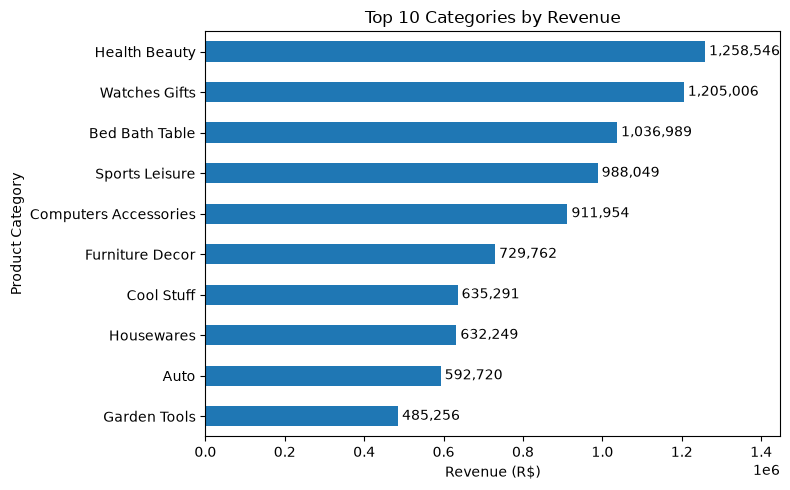

In [16]:
category_revenue_clean = category_revenue.head(10).copy()
category_revenue_clean.index = category_revenue_clean.index.str.replace('_', ' ').str.title()

ax = category_revenue_clean.plot(kind='barh', figsize=(8,5), title='Top 10 Categories by Revenue')
plt.xlabel('Revenue (R$)')
plt.ylabel('Product Category')
plt.gca().invert_yaxis()

for i, value in enumerate(category_revenue_clean):
    ax.text(value, i, f' {value:,.0f}', va='center')

plt.xlim(0, category_revenue_clean.max() * 1.15)
plt.tight_layout()
plt.show()

**Visualizing Revenue By States**

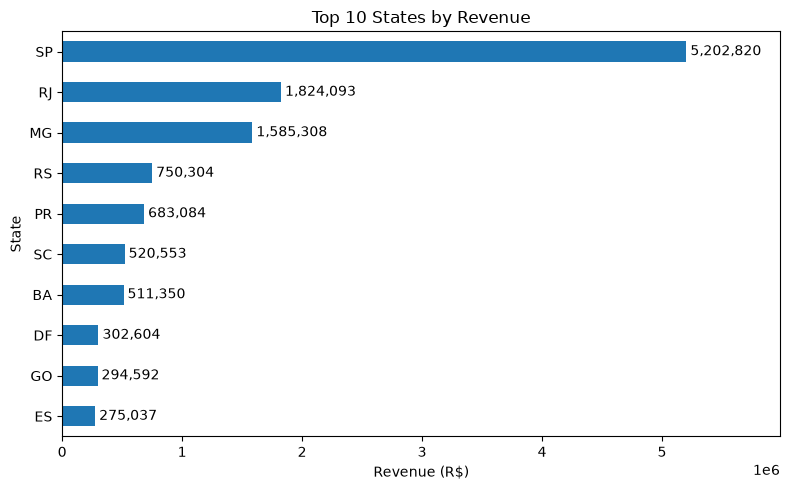

In [17]:
state_revenue_clean = state_revenue.head(10).copy()

ax = state_revenue_clean.plot(kind='barh', figsize=(8,5), title='Top 10 States by Revenue', legend=False)
plt.xlabel('Revenue (R$)')
plt.ylabel('State')
plt.gca().invert_yaxis()

for i, value in enumerate(state_revenue_clean):
    ax.text(value, i, f' {value:,.0f}', va='center')

plt.xlim(0, state_revenue_clean.max() * 1.15)
plt.tight_layout()
plt.show()

**Visualizing Review Score By Late Vs On Time Deliveries**

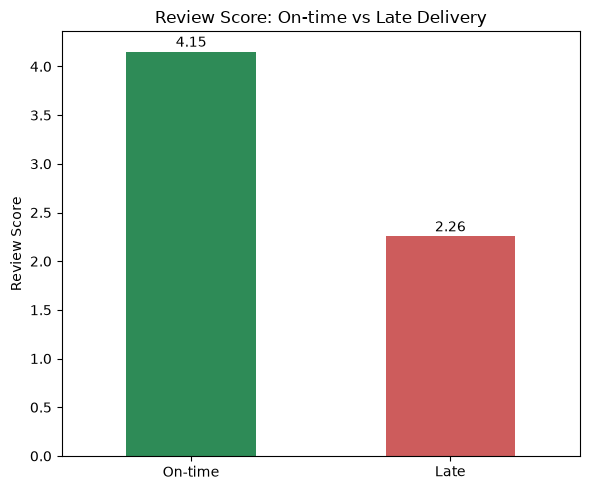

In [18]:
ax = review_by_late.plot(kind='bar', figsize=(6,5), title='Review Score: On-time vs Late Delivery', color=['seagreen', 'indianred'])
plt.xticks([0, 1], ['On-time', 'Late'], rotation=0)
plt.ylabel('Review Score')
plt.xlabel('')

for i, value in enumerate(review_by_late):
    ax.text(i, value + 0.05, f'{value:.2f}', ha='center')

plt.tight_layout()
plt.show()

**Visualizing Late Delivery Rate by State**

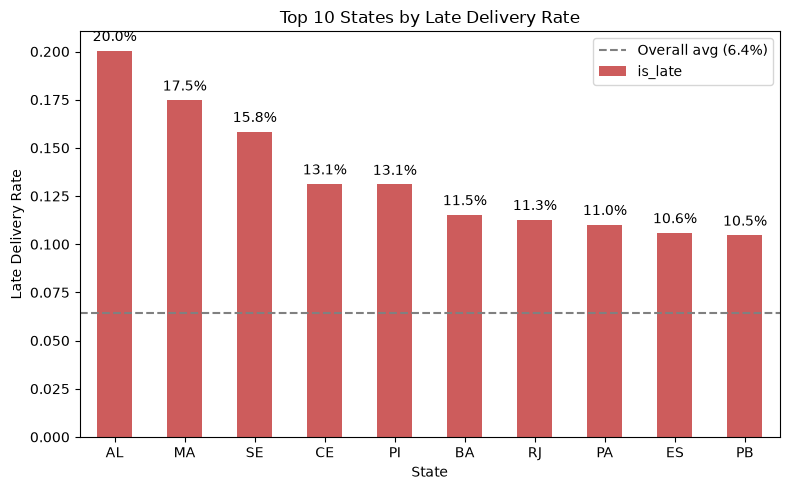

In [19]:
state_late_clean = state_late_rate.head(10).copy()

ax = state_late_clean.plot(kind='bar', figsize=(8,5), title='Top 10 States by Late Delivery Rate', color='indianred', legend=False)
plt.ylabel('Late Delivery Rate')
plt.xlabel('State')
plt.xticks(rotation=0)

for i, value in enumerate(state_late_clean):
    ax.text(i, value + 0.005, f'{value:.1%}', ha='center')

plt.axhline(y=df['is_late'].mean(), color='gray', linestyle='--', label=f'Overall avg ({df["is_late"].mean():.1%})')
plt.legend()
plt.tight_layout()
plt.show()

**Visualizing Revenue At Risk**

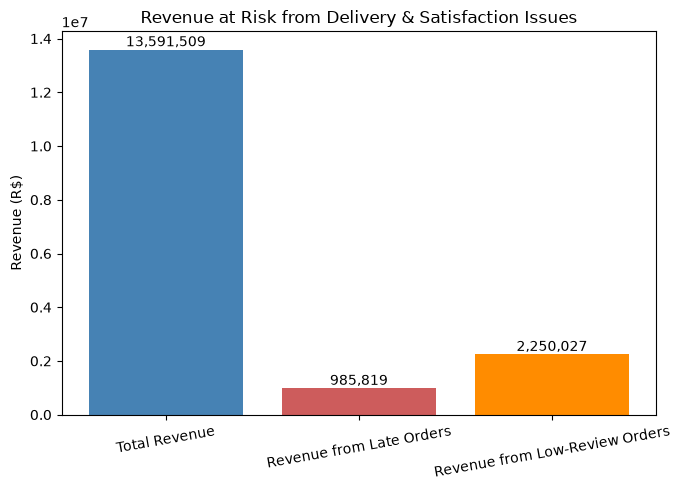

In [20]:
revenue_categories = ['Total Revenue', 'Revenue from Late Orders', 'Revenue from Low-Review Orders']
revenue_values = [revenue_total, revenue_late, revenue_low_review]

fig, ax = plt.subplots(figsize=(7,5))
bars = ax.bar(revenue_categories, revenue_values, color=['steelblue', 'indianred', 'darkorange'])
ax.set_title('Revenue at Risk from Delivery & Satisfaction Issues')
ax.set_ylabel('Revenue (R$)')

for bar, value in zip(bars, revenue_values):
    ax.text(bar.get_x() + bar.get_width()/2, value, f'{value:,.0f}', ha='center', va='bottom')

plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

**Summary**


**<h2 style="color:#1A5276;">Key Findings</h2>**

1. Revenue is heavily concentrated

Health & Beauty and Watches & Gifts are the top two categories, together generating over $2.4M — more than double the next closest category.
SP (São Paulo) alone generates $5.2M, more than the next three states (RJ, MG, RS) combined — it is clearly the platform's core market.

2. Late delivery is a real, measurable problem — 6.4% of all orders arrive late

Ten states have late-delivery rates well above the platform average, led by AL (20.0%) and MA (17.5%).
Importantly, SP performs well operationally (4.3% late, below average) — the top revenue market is not the problem.
RJ, the #2 revenue state, is an exception — it generates $1.8M in revenue but has an above-average late rate (11.3%), making it the clearest priority for logistics investment.

3. Late delivery is strongly linked to customer dissatisfaction

On-time orders average a review score of 4.15/5; late orders drop to 2.26/5 — a nearly 2-point decline.

4. Real revenue is at risk

$985,819 (7.3% of total revenue) is tied to orders that arrived late.
$2,250,027 (16.6% of total revenue) is tied to orders that received a low review score (1-2 stars).

5. The problem isn't limited to one region — it also shows up at the seller level

The platform's #1 revenue-generating seller has an above-average late rate (10.5% vs. 6.4%), indicating operational issues aren't confined to specific states.


**<h2 style="color:#C0392B;">Recommendations</h2>**

Prioritize logistics investment in RJ — it is a top-3 revenue state with a late-delivery rate nearly double the platform average.
Audit high-revenue sellers with above-average late rates, starting with the top seller identified above, since fixing a small number of large sellers could meaningfully reduce total late orders.
Treat delivery speed as a satisfaction lever, not just a logistics metric — the ~2-point review score drop for late orders suggests delivery reliability directly drives customer retention and ratings.
Use the $2.25M revenue-at-risk figure to justify operational investment — improving delivery reliability in underperforming states/sellers has a quantifiable revenue upside.

## Root Cause Analysis: Why Are Deliveries Late?

To move beyond diagnosis and toward an actionable solution, three potential drivers of late delivery were tested:

**1. Distance (strongest driver)**
Cross-state orders have a late rate of 7.6% vs. 4.4% for same-state orders — nearly double.

**2. Product category / item size**
Bulky/heavy categories show the highest late rates: `home_comfort_2` (13.3%), `furniture_mattress_and_upholstery` (13.2%), and `audio` (11.5%) — well above the 6.4% platform average.

**3. Approval delay (minor factor)**
Late orders average 12.9 hours to approval vs. 10.4 hours for on-time orders — a modest but present gap.

## Proposed Solutions

**1. Reduce cross-state shipping distance**
- Promote/incentivize regional sellers for high-volume states (e.g. "ships from your state" filter)
- Offer sellers a discount for maintaining regional warehouses
- Set more realistic estimated delivery windows for cross-state orders

**2. Create a dedicated logistics track for bulky items**
- Partner with specialized freight carriers for furniture/large-item categories
- Set longer, more accurate delivery estimates for these categories
- Flag underperforming sellers in bulky categories for logistics review

**3. Enforce a seller approval SLA**
- Require sellers to approve orders within 24 hours, with automated reminders

## Business Impact

Addressing the top driver — cross-state delivery delays — by improving regional fulfillment could meaningfully reduce the 7.6% cross-state late rate toward the 4.4% same-state benchmark. Applied against the R$985,819 in revenue currently tied to late orders, even a partial improvement represents a measurable, recoverable revenue opportunity.